In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('/content/Online Retail.xlsx')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
df['Cancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')

In [9]:
df['Cancelled'].value_counts()

,count
Cancelled,
False,532621
True,9288


In [10]:
(df['Quantity'] < 0).sum()

np.int64(10624)

In [11]:
df[df['Quantity'] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,True
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,True
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,True
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom,True
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,True
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,True
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom,True


In [12]:
negative_not_cancelled = df[
    (df['Quantity'] < 0) &
    (df['Cancelled'] == False)
]

In [13]:
len(negative_not_cancelled)

1336

In [14]:
(negative_not_cancelled['UnitPrice'] == 0).sum()

np.int64(1336)

In [15]:
(
    (negative_not_cancelled['UnitPrice'] == 0).sum()
    / len(negative_not_cancelled)
    * 100
)

np.float64(100.0)

In [16]:
negative_not_cancelled['Description'].value_counts(
    dropna=False
).head(30)

,count
Description,
NaN,862
check,120
damages,45
damaged,42
?,41
sold as set on dotcom,20
Damaged,14
thrown away,9
"Unsaleable, destroyed.",9


In [17]:
negative_not_cancelled['CustomerID'].isnull().sum()

np.int64(1336)

In [18]:
clean_sales = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0) &
    (df['Cancelled'] == False)
].copy()

In [19]:
clean_sales.shape

(530104, 9)

In [20]:
clean_sales['Revenue'] = (
    clean_sales['Quantity'] * clean_sales['UnitPrice']
)

In [21]:
clean_sales[
    [
        'InvoiceNo',
        'Description',
        'Quantity',
        'UnitPrice',
        'Revenue'
    ]
].head(10)

,InvoiceNo,Description,Quantity,UnitPrice,Revenue
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,536365,WHITE METAL LANTERN,6,3.39,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34
5,536365,SET 7 BABUSHKA NESTING BOXES,2,7.65,15.30
6,536365,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25,25.50
7,536366,HAND WARMER UNION JACK,6,1.85,11.10
8,536366,HAND WARMER RED POLKA DOT,6,1.85,11.10
9,536367,ASSORTED COLOUR BIRD ORNAMENT,32,1.69,54.08


In [22]:
clean_sales['Quantity'].min()

1

In [23]:
clean_sales['UnitPrice'].min()

0.001

In [24]:
clean_sales['Cancelled'].value_counts()

,count
Cancelled,
False,530104


In [25]:
total_revenue = clean_sales['Revenue'].sum()

In [26]:
total_orders = clean_sales['InvoiceNo'].nunique()

In [27]:
aov = total_revenue / total_orders

In [28]:
print('Total Revenue:', round(total_revenue, 2))
print('Total Orders:', total_orders)
print('AOV:', round(aov, 2))

Total Revenue: 10666684.54
Total Orders: 19960
AOV: 534.4


In [29]:
clean_sales['InvoiceDate'].dtype

dtype('<M8[ns]')

In [30]:
clean_sales['YearMonth'] = (clean_sales['InvoiceDate'].dt.to_period('M').astype(str))

In [31]:
clean_sales[['InvoiceDate', 'YearMonth']].head(10)

,InvoiceDate,YearMonth
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12
5,2010-12-01 08:26:00,2010-12
6,2010-12-01 08:26:00,2010-12
7,2010-12-01 08:28:00,2010-12
8,2010-12-01 08:28:00,2010-12
9,2010-12-01 08:34:00,2010-12


In [32]:
monthly_revenue = (clean_sales.groupby('YearMonth')['Revenue'].sum().reset_index())

In [33]:
monthly_revenue

,YearMonth,Revenue
0,2010-12,823746.140
1,2011-01,691364.560
2,2011-02,523631.890
3,2011-03,717639.360
4,2011-04,537808.621
5,2011-05,770536.020
6,2011-06,761739.900
7,2011-07,719221.191
8,2011-08,759138.380
9,2011-09,1058590.172


In [34]:
monthly_revenue.sort_values(
    'Revenue',
    ascending=False
).head()

,YearMonth,Revenue
11,2011-11,1509496.330
10,2011-10,1154979.300
9,2011-09,1058590.172
0,2010-12,823746.140
5,2011-05,770536.020


In [35]:
import matplotlib.pyplot as plt

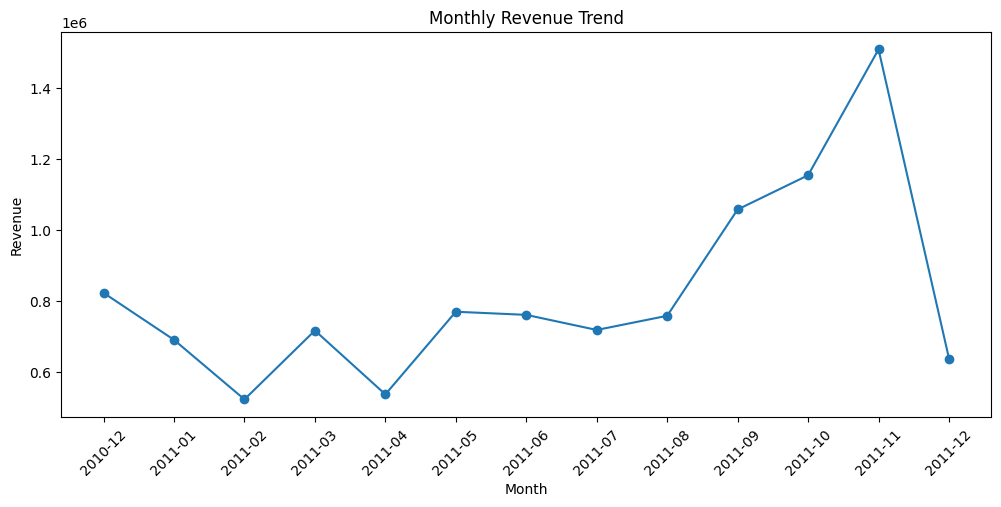

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue['YearMonth'],
    monthly_revenue['Revenue'],
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')

plt.xticks(rotation=45)

plt.show()

In [37]:
monthly_orders = (
    clean_sales
    .groupby('YearMonth')['InvoiceNo']
    .nunique()
    .reset_index(name='Orders')
)

In [38]:
monthly_orders

,YearMonth,Orders
0,2010-12,1559
1,2011-01,1086
2,2011-02,1100
3,2011-03,1454
4,2011-04,1246
5,2011-05,1681
6,2011-06,1533
7,2011-07,1475
8,2011-08,1361
9,2011-09,1837


In [39]:
monthly_summary = monthly_revenue.merge(monthly_orders,on='YearMonth')

In [40]:
monthly_summary['AOV'] = (monthly_summary['Revenue'] / monthly_summary['Orders'])

In [41]:
monthly_summary

,YearMonth,Revenue,Orders,AOV
0,2010-12,823746.140,1559,528.381103
1,2011-01,691364.560,1086,636.615617
2,2011-02,523631.890,1100,476.028991
3,2011-03,717639.360,1454,493.562146
4,2011-04,537808.621,1246,431.628107
5,2011-05,770536.020,1681,458.379548
6,2011-06,761739.900,1533,496.894912
7,2011-07,719221.191,1475,487.607587
8,2011-08,759138.380,1361,557.779853
9,2011-09,1058590.172,1837,576.260300


In [42]:
clean_sales['Date'] = clean_sales['InvoiceDate'].dt.date

In [43]:
monthly_days=(clean_sales.groupby('YearMonth')['Date'].nunique().reset_index(name='ActiveDays'))

In [44]:
monthly_days

,YearMonth,ActiveDays
0,2010-12,20
1,2011-01,24
2,2011-02,24
3,2011-03,27
4,2011-04,21
5,2011-05,25
6,2011-06,26
7,2011-07,26
8,2011-08,26
9,2011-09,26


In [45]:
monthly_summary = monthly_summary.merge(monthly_days,on='YearMonth')

In [46]:
monthly_summary

,YearMonth,Revenue,Orders,AOV,ActiveDays
0,2010-12,823746.140,1559,528.381103,20
1,2011-01,691364.560,1086,636.615617,24
2,2011-02,523631.890,1100,476.028991,24
3,2011-03,717639.360,1454,493.562146,27
4,2011-04,537808.621,1246,431.628107,21
5,2011-05,770536.020,1681,458.379548,25
6,2011-06,761739.900,1533,496.894912,26
7,2011-07,719221.191,1475,487.607587,26
8,2011-08,759138.380,1361,557.779853,26
9,2011-09,1058590.172,1837,576.260300,26


In [47]:
monthly_summary['OrdersPerDay']= (monthly_summary['Orders'] / monthly_summary['ActiveDays'])

In [48]:
monthly_summary

,YearMonth,Revenue,Orders,AOV,ActiveDays,OrdersPerDay
0,2010-12,823746.140,1559,528.381103,20,77.950000
1,2011-01,691364.560,1086,636.615617,24,45.250000
2,2011-02,523631.890,1100,476.028991,24,45.833333
3,2011-03,717639.360,1454,493.562146,27,53.851852
4,2011-04,537808.621,1246,431.628107,21,59.333333
5,2011-05,770536.020,1681,458.379548,25,67.240000
6,2011-06,761739.900,1533,496.894912,26,58.961538
7,2011-07,719221.191,1475,487.607587,26,56.730769
8,2011-08,759138.380,1361,557.779853,26,52.346154
9,2011-09,1058590.172,1837,576.260300,26,70.653846


In [49]:
monthly_summary['RevenuePerDay'] = (monthly_summary['Revenue'] / monthly_summary['ActiveDays'])

In [50]:
monthly_summary[['YearMonth', 'Revenue', 'Orders', 'AOV', 'ActiveDays', 'OrdersPerDay', 'RevenuePerDay']]

,YearMonth,Revenue,Orders,AOV,ActiveDays,OrdersPerDay,RevenuePerDay
0,2010-12,823746.140,1559,528.381103,20,77.950000,41187.307000
1,2011-01,691364.560,1086,636.615617,24,45.250000,28806.856667
2,2011-02,523631.890,1100,476.028991,24,45.833333,21817.995417
3,2011-03,717639.360,1454,493.562146,27,53.851852,26579.235556
4,2011-04,537808.621,1246,431.628107,21,59.333333,25609.934333
5,2011-05,770536.020,1681,458.379548,25,67.240000,30821.440800
6,2011-06,761739.900,1533,496.894912,26,58.961538,29297.688462
7,2011-07,719221.191,1475,487.607587,26,56.730769,27662.353500
8,2011-08,759138.380,1361,557.779853,26,52.346154,29197.630000
9,2011-09,1058590.172,1837,576.260300,26,70.653846,40715.006615


In [51]:
full_months = monthly_summary[monthly_summary['YearMonth'] != '2011-12'].copy()

In [52]:
full_months.sort_values('Revenue',ascending=False)

,YearMonth,Revenue,Orders,AOV,ActiveDays,OrdersPerDay,RevenuePerDay
11,2011-11,1509496.330,2769,545.141325,26,106.500000,58057.551154
10,2011-10,1154979.300,2040,566.166324,26,78.461538,44422.280769
9,2011-09,1058590.172,1837,576.260300,26,70.653846,40715.006615
0,2010-12,823746.140,1559,528.381103,20,77.950000,41187.307000
5,2011-05,770536.020,1681,458.379548,25,67.240000,30821.440800
6,2011-06,761739.900,1533,496.894912,26,58.961538,29297.688462
8,2011-08,759138.380,1361,557.779853,26,52.346154,29197.630000
7,2011-07,719221.191,1475,487.607587,26,56.730769,27662.353500
3,2011-03,717639.360,1454,493.562146,27,53.851852,26579.235556
1,2011-01,691364.560,1086,636.615617,24,45.250000,28806.856667


In [53]:
monthly_summary[monthly_summary['YearMonth'].isin(['2011-11','2011-12'])]

,YearMonth,Revenue,Orders,AOV,ActiveDays,OrdersPerDay,RevenuePerDay
11,2011-11,1509496.33,2769,545.141325,26,106.500,58057.551154
12,2011-12,638792.68,819,779.966642,8,102.375,79849.085000


In [54]:
nov = monthly_summary[monthly_summary['YearMonth'] == '2011-11'].iloc[0]

In [55]:
dec = monthly_summary[monthly_summary['YearMonth'] == '2011-12'].iloc[0]

In [56]:
orders_per_day_change =(dec['OrdersPerDay'] / nov['OrdersPerDay'] - 1)*100

In [57]:
revenue_per_day_change =(dec['RevenuePerDay'] / nov['RevenuePerDay'] - 1)*100

In [58]:
aov_change = (dec['AOV'] / nov['AOV'] - 1)*100

In [59]:
print('Orders per Day Change:', round(orders_per_day_change, 2), '%')
print('Revenue per Day Change:', round(revenue_per_day_change, 2), '%')
print('AOV Change:', round(aov_change, 2), '%')

Orders per Day Change: -3.87 %
Revenue per Day Change: 37.53 %
AOV Change: 43.08 %


In [60]:
clean_sales['Description'].isnull().sum()

np.int64(0)

In [61]:
product_sales= clean_sales.dropna(subset=['Description']).copy()

In [62]:
product_summary = (product_sales.groupby('Description').agg(UnitsSold=('Quantity','sum'),Revenue=('Revenue','sum'),Orders=('InvoiceNo','nunique')).reset_index())

In [63]:
product_summary

,Description,UnitsSold,Revenue,Orders
0,4 PURPLE FLOCK DINNER CANDLES,144,290.80,38
1,50'S CHRISTMAS GIFT BAG LARGE,1915,2343.63,129
2,DOLLY GIRL BEAKER,2455,2891.25,174
3,I LOVE LONDON MINI BACKPACK,389,1628.17,86
4,I LOVE LONDON MINI RUCKSACK,1,4.15,1
...,...,...,...,...
4021,ZINC T-LIGHT HOLDER STARS SMALL,5089,4197.83,274
4022,ZINC TOP 2 DOOR WOODEN SHELF,13,270.08,12
4023,ZINC WILLIE WINKIE CANDLE STICK,2934,2713.55,268
4024,ZINC WIRE KITCHEN ORGANISER,30,239.97,16


In [64]:
top_units = product_summary.sort_values('UnitsSold',ascending=False).head(10)

In [65]:
top_units

,Description,UnitsSold,Revenue,Orders
2387,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
2052,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
3934,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047,13841.85,535
1816,JUMBO BAG RED RETROSPOT,48474,94340.05,2089
3844,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2256
2681,POPCORN HOLDER,36761,34298.87,803
227,ASSORTED COLOUR BIRD ORNAMENT,36461,59094.93,1455
2337,PACK OF 72 RETROSPOT CAKE CASES,36419,21259.10,1320
2741,RABBIT NIGHT LIGHT,30788,66964.99,994
2107,MINI PAINT SET VINTAGE,26633,16937.82,380


In [66]:
top_revenue = product_summary.sort_values('Revenue',ascending=False).head(10)

In [67]:
top_revenue

,Description,UnitsSold,Revenue,Orders
1067,DOTCOM POSTAGE,706,206248.77,706
2853,REGENCY CAKESTAND 3 TIER,13879,174484.74,1988
2387,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
3844,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2256
2413,PARTY BUNTING,18295,99504.33,1685
1816,JUMBO BAG RED RETROSPOT,48474,94340.05,2089
2052,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
2192,Manual,7225,78112.82,290
2692,POSTAGE,3150,78101.88,1126
2741,RABBIT NIGHT LIGHT,30788,66964.99,994


In [68]:
top_orders = product_summary.sort_values('Orders',ascending=False).head(10)

In [69]:
top_orders

,Description,UnitsSold,Revenue,Orders
3844,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2256
1816,JUMBO BAG RED RETROSPOT,48474,94340.05,2089
2853,REGENCY CAKESTAND 3 TIER,13879,174484.74,1988
2413,PARTY BUNTING,18295,99504.33,1685
2003,LUNCH BAG RED RETROSPOT,19353,35752.01,1564
227,ASSORTED COLOUR BIRD ORNAMENT,36461,59094.93,1455
3133,SET OF 3 CAKE TINS PANTRY DESIGN,7493,38158.39,1385
2337,PACK OF 72 RETROSPOT CAKE CASES,36419,21259.10,1320
1995,LUNCH BAG BLACK SKULL.,12240,22421.21,1273
2197,NATURAL SLATE HEART CHALKBOARD,9172,28147.96,1249


In [70]:
total_product_revenue = product_summary['Revenue'].sum()

In [71]:
top10_revenue = (product_summary.sort_values('Revenue',ascending=False).head(10)['Revenue'].sum())

In [72]:
top10_share = (top10_revenue / total_product_revenue)*100
print('Top 10 Revenue Share:' , round(top10_share,2), '%')

Top 10 Revenue Share: 10.82 %


In [73]:
top20_revenue = (product_summary.sort_values('Revenue',ascending=False).head(20)['Revenue'].sum())

In [74]:
top20_share = (top20_revenue / total_product_revenue)*100
print('Top 20 Revenue Share:' , round(top20_share,2), '%')

Top 20 Revenue Share: 15.1 %


In [75]:
import matplotlib.pyplot as plt

In [76]:
top_revenue_plot = (product_summary.sort_values('Revenue',ascending=False).head(10).sort_values('Revenue'))

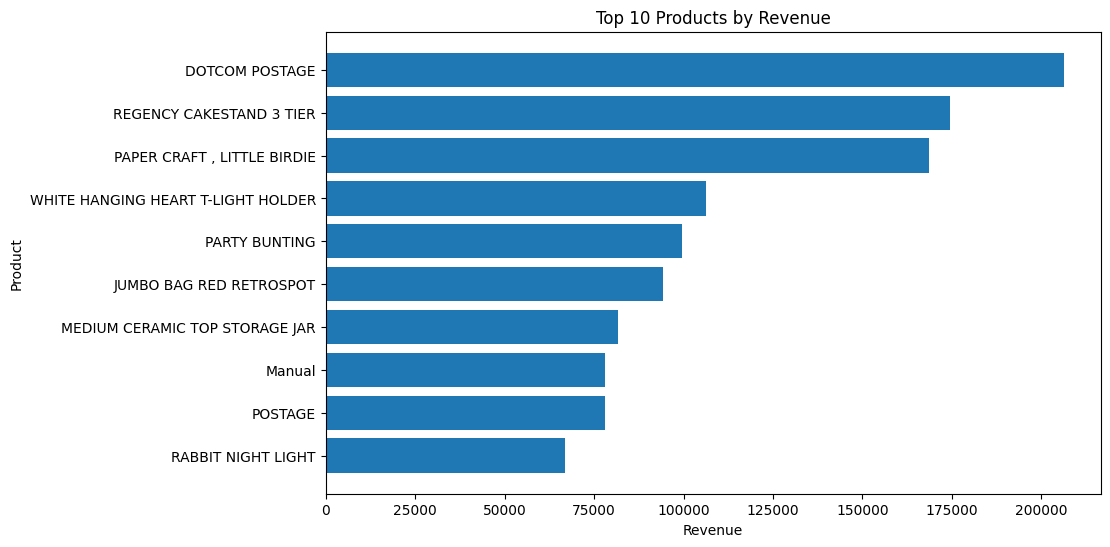

In [77]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_revenue_plot['Description'],
    top_revenue_plot['Revenue']
)

plt.xlabel('Revenue')
plt.ylabel('Product')
plt.title('Top 10 Products by Revenue')

plt.show()

In [78]:
top_units

,Description,UnitsSold,Revenue,Orders
2387,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
2052,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
3934,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047,13841.85,535
1816,JUMBO BAG RED RETROSPOT,48474,94340.05,2089
3844,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2256
2681,POPCORN HOLDER,36761,34298.87,803
227,ASSORTED COLOUR BIRD ORNAMENT,36461,59094.93,1455
2337,PACK OF 72 RETROSPOT CAKE CASES,36419,21259.10,1320
2741,RABBIT NIGHT LIGHT,30788,66964.99,994
2107,MINI PAINT SET VINTAGE,26633,16937.82,380


In [79]:
top_revenue

,Description,UnitsSold,Revenue,Orders
1067,DOTCOM POSTAGE,706,206248.77,706
2853,REGENCY CAKESTAND 3 TIER,13879,174484.74,1988
2387,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
3844,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2256
2413,PARTY BUNTING,18295,99504.33,1685
1816,JUMBO BAG RED RETROSPOT,48474,94340.05,2089
2052,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
2192,Manual,7225,78112.82,290
2692,POSTAGE,3150,78101.88,1126
2741,RABBIT NIGHT LIGHT,30788,66964.99,994


In [80]:
product_sales[product_sales['Description'].str.contains('POSTAGE',case=False,na=False)]['Description'].value_counts()

,count
Description,
POSTAGE,1126
DOTCOM POSTAGE,706


In [81]:
real_products = product_sales[~product_sales['Description'].str.contains('POSTAGE',case=False,na=False)].copy()

In [82]:
product_summary_clean = (
    real_products
    .groupby('Description')
    .agg(
        UnitsSold=('Quantity', 'sum'),
        Revenue=('Revenue', 'sum'),
        Orders=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

In [83]:
top_revenue_clean = (
    product_summary_clean
    .sort_values(
        'Revenue',
        ascending=False
    )
    .head(10)
)

top_revenue_clean

,Description,UnitsSold,Revenue,Orders
2851,REGENCY CAKESTAND 3 TIER,13879,174484.74,1988
2386,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
3842,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2256
2412,PARTY BUNTING,18295,99504.33,1685
1815,JUMBO BAG RED RETROSPOT,48474,94340.05,2089
2051,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
2191,Manual,7225,78112.82,290
2739,RABBIT NIGHT LIGHT,30788,66964.99,994
2380,PAPER CHAIN KIT 50'S CHRISTMAS,19355,64952.29,1160
227,ASSORTED COLOUR BIRD ORNAMENT,36461,59094.93,1455


In [84]:
top_units_clean = (
    product_summary_clean
    .sort_values(
        'UnitsSold',
        ascending=False
    )
    .head(10)
)

top_units_clean

,Description,UnitsSold,Revenue,Orders
2386,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
2051,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
3932,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047,13841.85,535
1815,JUMBO BAG RED RETROSPOT,48474,94340.05,2089
3842,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2256
2680,POPCORN HOLDER,36761,34298.87,803
227,ASSORTED COLOUR BIRD ORNAMENT,36461,59094.93,1455
2336,PACK OF 72 RETROSPOT CAKE CASES,36419,21259.10,1320
2739,RABBIT NIGHT LIGHT,30788,66964.99,994
2106,MINI PAINT SET VINTAGE,26633,16937.82,380


In [85]:
total_real_product_revenue = (
    product_summary_clean['Revenue'].sum()
)

In [86]:
top10_real_revenue =(product_summary_clean.sort_values('Revenue',ascending=False).head(10)['Revenue'].sum())

In [87]:
top10_real_share = (
    top10_real_revenue
    / total_real_product_revenue
    * 100
)

print(
    'Top 10 Revenue Share:',
    round(top10_real_share, 2),
    '%'
)

Top 10 Revenue Share: 9.57 %


In [88]:
top20_real_revenue = (
    product_summary_clean
    .sort_values(
        'Revenue',
        ascending=False
    )
    .head(20)['Revenue']
    .sum()
)

top20_real_share = (
    top20_real_revenue
    / total_real_product_revenue
    * 100
)

print(
    'Top 20 Revenue Share:',
    round(top20_real_share, 2),
    '%'
)

Top 20 Revenue Share: 13.47 %


In [89]:
top_revenue_plot = (
    product_summary_clean
    .sort_values(
        'Revenue',
        ascending=False
    )
    .head(10)
    .sort_values('Revenue')
)

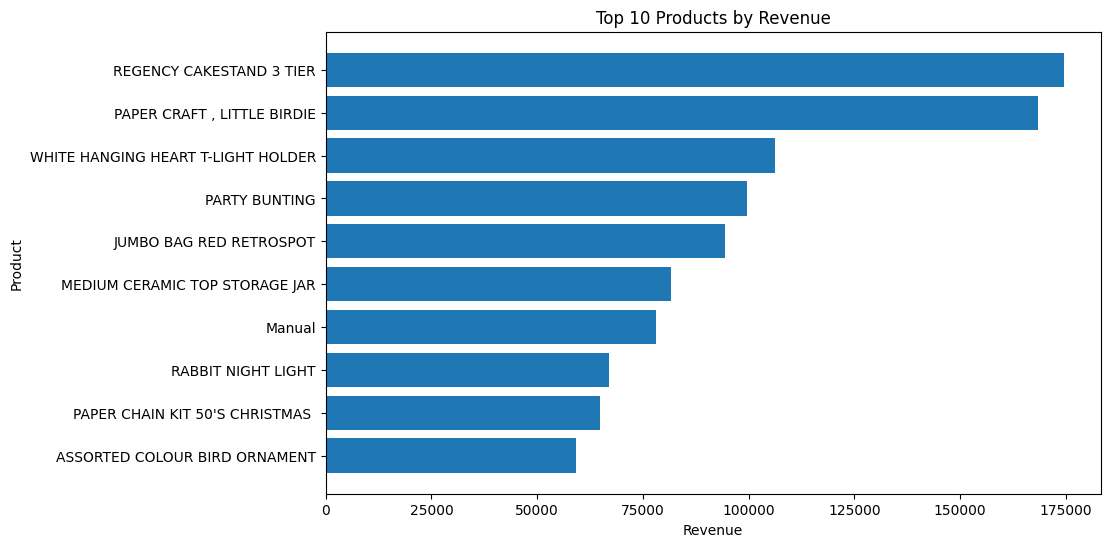

In [90]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_revenue_plot['Description'],
    top_revenue_plot['Revenue']
)

plt.xlabel('Revenue')
plt.ylabel('Product')
plt.title('Top 10 Products by Revenue')

plt.show()

In [91]:
manual_rows = product_sales[product_sales['Description']== 'Manual'].copy()

In [92]:
manual_rows.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled,Revenue,YearMonth,Date
2239,536569,M,Manual,1,2010-12-01 15:35:00,1.25,16274.0,United Kingdom,False,1.25,2010-12,2010-12-01
2250,536569,M,Manual,1,2010-12-01 15:35:00,18.95,16274.0,United Kingdom,False,18.95,2010-12,2010-12-01
5684,536865,M,Manual,1,2010-12-03 11:28:00,2.55,NaN,United Kingdom,False,2.55,2010-12,2010-12-03
6798,536981,M,Manual,2,2010-12-03 14:26:00,0.85,14723.0,United Kingdom,False,1.70,2010-12,2010-12-03
7976,537077,M,Manual,12,2010-12-05 11:59:00,0.42,17062.0,United Kingdom,False,5.04,2010-12,2010-12-05
8530,537137,M,Manual,36,2010-12-05 12:43:00,0.85,16327.0,United Kingdom,False,30.60,2010-12,2010-12-05
8587,537140,M,Manual,1,2010-12-05 12:53:00,0.42,12748.0,United Kingdom,False,0.42,2010-12,2010-12-05
8588,537140,M,Manual,1,2010-12-05 12:53:00,0.85,12748.0,United Kingdom,False,0.85,2010-12,2010-12-05
9326,537199,M,Manual,1,2010-12-05 14:06:00,0.65,15894.0,United Kingdom,False,0.65,2010-12,2010-12-05
9575,537208,M,Manual,4,2010-12-05 15:12:00,0.85,15889.0,United Kingdom,False,3.40,2010-12,2010-12-05


In [93]:
len(manual_rows)

322

In [94]:
manual_rows['UnitPrice'].describe()

,UnitPrice
count,322.000000
mean,230.151491
std,648.680976
min,0.060000
25%,0.792500
50%,1.800000
75%,38.750000
max,4287.630000


In [95]:
manual_revenue = manual_rows['Revenue'].sum()
print('Manual Revenue:', round(manual_revenue, 2))

Manual Revenue: 78112.82


In [96]:
manual_share =(manual_revenue / total_real_product_revenue *100)
print('Manual Revenue Share:',round(manual_share,2),'%')

Manual Revenue Share: 0.75 %


In [97]:
special_items = product_sales[
    product_sales['Description'].str.contains(
        'FEE|CHARGE|COMMISSION|DISCOUNT|MANUAL',
        case=False,
        na=False,
        regex=True
    )
]

special_items['Description'].value_counts()

,count
Description,
SET OF TEA COFFEE SUGAR TINS PANTRY,474
"SET 3 RETROSPOT TEA,COFFEE,SUGAR",439
LONDON BUS COFFEE MUG,325
Manual,322
QUEENS GUARD COFFEE MUG,274
COFFEE MUG APPLES DESIGN,263
COFFEE MUG CAT + BIRD DESIGN,256
COFFEE MUG PEARS DESIGN,214
COFFEE MUG DOG + BALL DESIGN,199


In [98]:
non_product_keywords = (
    'POSTAGE|MANUAL|FEE|CHARGE|COMMISSION|DISCOUNT'
)

final_products = product_sales[
    ~product_sales['Description'].str.contains(
        non_product_keywords,
        case=False,
        na=False,
        regex=True
    )
].copy()

In [99]:
final_product_summary = (
    final_products
    .groupby('Description')
    .agg(
        UnitsSold=('Quantity', 'sum'),
        Revenue=('Revenue', 'sum'),
        Orders=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

In [100]:
final_product_summary['RevenuePerUnit'] = (
    final_product_summary['Revenue']
    / final_product_summary['UnitsSold']
)

In [101]:
top_units_final = (
    final_product_summary
    .sort_values('UnitsSold', ascending=False)
    .head(10)
)

top_units_final

,Description,UnitsSold,Revenue,Orders,RevenuePerUnit
2365,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,2.080000
2032,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247,1.047005
3899,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047,13841.85,535,0.251455
1798,JUMBO BAG RED RETROSPOT,48474,94340.05,2089,1.946199
3810,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2256,2.805225
2658,POPCORN HOLDER,36761,34298.87,803,0.933023
226,ASSORTED COLOUR BIRD ORNAMENT,36461,59094.93,1455,1.620771
2316,PACK OF 72 RETROSPOT CAKE CASES,36419,21259.10,1320,0.583737
2716,RABBIT NIGHT LIGHT,30788,66964.99,994,2.175035
2087,MINI PAINT SET VINTAGE,26633,16937.82,380,0.635971


In [102]:
top_revenue_final = (
    final_product_summary
    .sort_values('Revenue', ascending=False)
    .head(10)
)

top_revenue_final

,Description,UnitsSold,Revenue,Orders,RevenuePerUnit
2827,REGENCY CAKESTAND 3 TIER,13879,174484.74,1988,12.571852
2365,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,2.080000
3810,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2256,2.805225
2391,PARTY BUNTING,18295,99504.33,1685,5.438881
1798,JUMBO BAG RED RETROSPOT,48474,94340.05,2089,1.946199
2032,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247,1.047005
2716,RABBIT NIGHT LIGHT,30788,66964.99,994,2.175035
2359,PAPER CHAIN KIT 50'S CHRISTMAS,19355,64952.29,1160,3.355840
226,ASSORTED COLOUR BIRD ORNAMENT,36461,59094.93,1455,1.620771
742,CHILLI LIGHTS,10306,54117.76,661,5.251093


In [103]:
top_units_names = set(
    top_units_final['Description']
)

top_revenue_names = set(
    top_revenue_final['Description']
)

common_products = (
    top_units_names & top_revenue_names
)

print('同时进入两个 Top 10 的商品数量：',
      len(common_products))

print('\n这些商品是：')

for product in common_products:
    print(product)

同时进入两个 Top 10 的商品数量： 6

这些商品是：
RABBIT NIGHT LIGHT
MEDIUM CERAMIC TOP STORAGE JAR
PAPER CRAFT , LITTLE BIRDIE
JUMBO BAG RED RETROSPOT
WHITE HANGING HEART T-LIGHT HOLDER
ASSORTED COLOUR BIRD ORNAMENT


In [104]:
total_real_revenue = (
    final_product_summary['Revenue'].sum()
)

top10_revenue = (
    final_product_summary
    .sort_values('Revenue', ascending=False)
    .head(10)['Revenue']
    .sum()
)

top20_revenue = (
    final_product_summary
    .sort_values('Revenue', ascending=False)
    .head(20)['Revenue']
    .sum()
)

top10_share = (
    top10_revenue / total_real_revenue * 100
)

top20_share = (
    top20_revenue / total_real_revenue * 100
)

print(
    'Top 10 Revenue Share:',
    round(top10_share, 2),
    '%'
)

print(
    'Top 20 Revenue Share:',
    round(top20_share, 2),
    '%'
)

Top 10 Revenue Share: 9.51 %
Top 20 Revenue Share: 13.28 %


In [105]:
paper_craft = final_products[
    final_products['Description']
    .str.contains(
        'PAPER CRAFT',
        case=False,
        na=False
    )
]

paper_craft[
    [
        'InvoiceNo',
        'Quantity',
        'UnitPrice',
        'Revenue',
        'CustomerID'
    ]
].sort_values(
    'Quantity',
    ascending=False
).head(20)

,InvoiceNo,Quantity,UnitPrice,Revenue,CustomerID
540421,581483,80995,2.08,168469.6,16446.0


In [106]:
final_product_summary = (
    final_products
    .groupby('Description')
    .agg(
        UnitsSold=('Quantity', 'sum'),
        Revenue=('Revenue', 'sum'),
        Orders=('InvoiceNo', 'nunique'),
        Customers=('CustomerID', 'nunique')
    )
    .reset_index()
)

In [107]:
final_product_summary['UnitsPerOrder'] = (
    final_product_summary['UnitsSold']
    / final_product_summary['Orders']
)

In [108]:
paper_craft = final_products[final_products['Description'].str.contains('PAPER CRAFT', case=False,na=False)]

In [109]:
paper_craft[
    [
        'InvoiceNo',
        'Quantity',
        'UnitPrice',
        'Revenue',
        'CustomerID'
    ]
].sort_values(
    'Quantity',
    ascending=False
).head(20)

,InvoiceNo,Quantity,UnitPrice,Revenue,CustomerID
540421,581483,80995,2.08,168469.6,16446.0


In [110]:
final_product_summary = (
    final_products
    .groupby('Description')
    .agg(
        UnitsSold=('Quantity', 'sum'),
        Revenue=('Revenue', 'sum'),
        Orders=('InvoiceNo', 'nunique'),
        Customers=('CustomerID', 'nunique')
    )
    .reset_index()
)

In [111]:
final_product_summary['UnitsPerOrder'] = (
    final_product_summary['UnitsSold']
    / final_product_summary['Orders']
)

In [112]:
top_revenue_final = (
    final_product_summary
    .sort_values(
        'Revenue',
        ascending=False
    )
    .head(10)
)

top_revenue_final

,Description,UnitsSold,Revenue,Orders,Customers,UnitsPerOrder
2827,REGENCY CAKESTAND 3 TIER,13879,174484.74,1988,881,6.981388
2365,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,1,80995.000000
3810,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2256,856,16.795656
2391,PARTY BUNTING,18295,99504.33,1685,708,10.857567
1798,JUMBO BAG RED RETROSPOT,48474,94340.05,2089,635,23.204404
2032,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247,138,315.923077
2716,RABBIT NIGHT LIGHT,30788,66964.99,994,450,30.973843
2359,PAPER CHAIN KIT 50'S CHRISTMAS,19355,64952.29,1160,613,16.685345
226,ASSORTED COLOUR BIRD ORNAMENT,36461,59094.93,1455,678,25.059107
742,CHILLI LIGHTS,10306,54117.76,661,205,15.591528


In [113]:
top_units_final=(final_product_summary.sort_values('UnitsSold',ascending=False).head(10))

In [114]:
top_units_final

,Description,UnitsSold,Revenue,Orders,Customers,UnitsPerOrder
2365,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,1,80995.000000
2032,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247,138,315.923077
3899,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047,13841.85,535,307,102.891589
1798,JUMBO BAG RED RETROSPOT,48474,94340.05,2089,635,23.204404
3810,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2256,856,16.795656
2658,POPCORN HOLDER,36761,34298.87,803,295,45.779577
226,ASSORTED COLOUR BIRD ORNAMENT,36461,59094.93,1455,678,25.059107
2316,PACK OF 72 RETROSPOT CAKE CASES,36419,21259.10,1320,635,27.590152
2716,RABBIT NIGHT LIGHT,30788,66964.99,994,450,30.973843
2087,MINI PAINT SET VINTAGE,26633,16937.82,380,213,70.086842


In [115]:
total_real_revenue = final_product_summary['Revenue'].sum()

In [116]:
top10_revenue=(final_product_summary.sort_values('Revenue',ascending=False).head(10)['Revenue'].sum())

In [117]:
top10_share = (
    top10_revenue
    / total_real_revenue
    * 100
)

print(
    'Top 10 Revenue Share:',
    round(top10_share, 2),
    '%'
)

Top 10 Revenue Share: 9.51 %


In [118]:
top20_revenue = (final_product_summary.sort_values('Revenue',ascending=False).head(20)['Revenue'].sum())

In [119]:
top20_share = (
    top20_revenue
    / total_real_revenue
    * 100
)

print(
    'Top 20 Revenue Share:',
    round(top20_share, 2),
    '%'
)

Top 20 Revenue Share: 13.28 %


In [120]:
products_without_extreme = final_products[
    final_products['Quantity'] < 80995
].copy()

In [121]:
summary_without_extreme = (
    products_without_extreme
    .groupby('Description')
    .agg(
        UnitsSold=('Quantity', 'sum'),
        Revenue=('Revenue', 'sum'),
        Orders=('InvoiceNo', 'nunique'),
        Customers=('CustomerID', 'nunique')
    )
    .reset_index()
)

In [122]:
summary_without_extreme.sort_values(
    'Revenue',
    ascending=False
).head(10)

,Description,UnitsSold,Revenue,Orders,Customers
2826,REGENCY CAKESTAND 3 TIER,13879,174484.74,1988,881
3809,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2256,856
2390,PARTY BUNTING,18295,99504.33,1685,708
1798,JUMBO BAG RED RETROSPOT,48474,94340.05,2089,635
2032,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247,138
2715,RABBIT NIGHT LIGHT,30788,66964.99,994,450
2359,PAPER CHAIN KIT 50'S CHRISTMAS,19355,64952.29,1160,613
226,ASSORTED COLOUR BIRD ORNAMENT,36461,59094.93,1455,678
742,CHILLI LIGHTS,10306,54117.76,661,205
3432,SPOTTY BUNTING,8327,42548.13,1140,571


In [123]:
summary_without_extreme.sort_values(
    'UnitsSold',
    ascending=False
).head(10)

,Description,UnitsSold,Revenue,Orders,Customers
2032,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247,138
3898,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047,13841.85,535,307
1798,JUMBO BAG RED RETROSPOT,48474,94340.05,2089,635
3809,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2256,856
2657,POPCORN HOLDER,36761,34298.87,803,295
226,ASSORTED COLOUR BIRD ORNAMENT,36461,59094.93,1455,678
2316,PACK OF 72 RETROSPOT CAKE CASES,36419,21259.10,1320,635
2715,RABBIT NIGHT LIGHT,30788,66964.99,994,450
2087,MINI PAINT SET VINTAGE,26633,16937.82,380,213
2282,PACK OF 12 LONDON TISSUES,26135,7980.92,512,195


In [124]:
country_summary = (
    clean_sales
    .groupby('Country')
    .agg(
        Revenue=('Revenue', 'sum'),
        Orders=('InvoiceNo', 'nunique'),
        Customers=('CustomerID', 'nunique')
    )
    .reset_index()
)

In [125]:
country_summary['AOV'] = (country_summary['Revenue'] / country_summary['Orders'])

In [126]:
country_summary.sort_values(
    'Revenue',
    ascending=False).head(10)


,Country,Revenue,Orders,Customers,AOV
36,United Kingdom,9025222.084,18019,3920,500.872528
24,Netherlands,285446.340,94,9,3036.663191
10,EIRE,283453.960,288,3,984.215139
14,Germany,228867.140,457,94,500.803370
13,France,209715.110,392,87,534.987526
0,Australia,138521.310,57,9,2430.198421
31,Spain,61577.110,90,30,684.190111
33,Switzerland,57089.900,54,21,1057.220370
3,Belgium,41196.340,98,25,420.370816
32,Sweden,38378.330,36,8,1066.064722


In [127]:
international_markets = country_summary[country_summary['Country']!= 'United Kingdom'].copy()

In [128]:
international_markets.sort_values(
    'Revenue',
    ascending=False
).head(10)

,Country,Revenue,Orders,Customers,AOV
24,Netherlands,285446.34,94,9,3036.663191
10,EIRE,283453.96,288,3,984.215139
14,Germany,228867.14,457,94,500.803370
13,France,209715.11,392,87,534.987526
0,Australia,138521.31,57,9,2430.198421
31,Spain,61577.11,90,30,684.190111
33,Switzerland,57089.90,54,21,1057.220370
3,Belgium,41196.34,98,25,420.370816
32,Sweden,38378.33,36,8,1066.064722
20,Japan,37416.37,19,8,1969.282632


In [129]:
international_markets.sort_values(
    'AOV',
    ascending=False
).head(10)

,Country,Revenue,Orders,Customers,AOV
30,Singapore,21279.29,7,1,3039.898571
24,Netherlands,285446.34,94,9,3036.663191
0,Australia,138521.31,57,9,2430.198421
20,Japan,37416.37,19,8,1969.282632
21,Lebanon,1693.88,1,1,1693.880000
16,Hong Kong,15691.80,11,0,1426.527273
4,Brazil,1143.60,1,1,1143.600000
32,Sweden,38378.33,36,8,1066.064722
33,Switzerland,57089.90,54,21,1057.220370
9,Denmark,18955.34,18,9,1053.074444


In [130]:
international_markets.sort_values(
    'Orders',
    ascending=False
).head(10)

,Country,Revenue,Orders,Customers,AOV
14,Germany,228867.14,457,94,500.803370
13,France,209715.11,392,87,534.987526
10,EIRE,283453.96,288,3,984.215139
3,Belgium,41196.34,98,25,420.370816
24,Netherlands,285446.34,94,9,3036.663191
31,Spain,61577.11,90,30,684.190111
27,Portugal,33747.10,58,19,581.846552
0,Australia,138521.31,57,9,2430.198421
33,Switzerland,57089.90,54,21,1057.220370
12,Finland,22546.08,41,12,549.904390


In [131]:
total_revenue_all = country_summary['Revenue'].sum()

In [132]:
country_summary['RevenueShare']= (country_summary['Revenue'] / total_revenue_all *100)

In [133]:
country_summary.sort_values(
    'RevenueShare',
    ascending=False
).head(10)

,Country,Revenue,Orders,Customers,AOV,RevenueShare
36,United Kingdom,9025222.084,18019,3920,500.872528,84.611315
24,Netherlands,285446.340,94,9,3036.663191,2.676055
10,EIRE,283453.960,288,3,984.215139,2.657376
14,Germany,228867.140,457,94,500.803370,2.145626
13,France,209715.110,392,87,534.987526,1.966076
0,Australia,138521.310,57,9,2430.198421,1.298635
31,Spain,61577.110,90,30,684.190111,0.577284
33,Switzerland,57089.900,54,21,1057.220370,0.535217
3,Belgium,41196.340,98,25,420.370816,0.386215
32,Sweden,38378.330,36,8,1066.064722,0.359796


In [134]:
international_markets.sort_values('AOV',ascending=False).head(10)

,Country,Revenue,Orders,Customers,AOV
30,Singapore,21279.29,7,1,3039.898571
24,Netherlands,285446.34,94,9,3036.663191
0,Australia,138521.31,57,9,2430.198421
20,Japan,37416.37,19,8,1969.282632
21,Lebanon,1693.88,1,1,1693.880000
16,Hong Kong,15691.80,11,0,1426.527273
4,Brazil,1143.60,1,1,1143.600000
32,Sweden,38378.33,36,8,1066.064722
33,Switzerland,57089.90,54,21,1057.220370
9,Denmark,18955.34,18,9,1053.074444


In [135]:
international_markets.sort_values('Customers',ascending=False).head(10)

,Country,Revenue,Orders,Customers,AOV
14,Germany,228867.14,457,94,500.803370
13,France,209715.11,392,87,534.987526
31,Spain,61577.11,90,30,684.190111
3,Belgium,41196.34,98,25,420.370816
33,Switzerland,57089.90,54,21,1057.220370
27,Portugal,33747.10,58,19,581.846552
19,Italy,17483.24,38,14,460.085263
12,Finland,22546.08,41,12,549.904390
1,Austria,10198.68,17,11,599.922353
25,Norway,36165.44,36,10,1004.595556


In [136]:
international_markets.sort_values('Orders',ascending=False).head(10)

,Country,Revenue,Orders,Customers,AOV
14,Germany,228867.14,457,94,500.803370
13,France,209715.11,392,87,534.987526
10,EIRE,283453.96,288,3,984.215139
3,Belgium,41196.34,98,25,420.370816
24,Netherlands,285446.34,94,9,3036.663191
31,Spain,61577.11,90,30,684.190111
27,Portugal,33747.10,58,19,581.846552
0,Australia,138521.31,57,9,2430.198421
33,Switzerland,57089.90,54,21,1057.220370
12,Finland,22546.08,41,12,549.904390


In [137]:
international_markets['RevenuePerCustomer'] = (international_markets['Revenue'] / international_markets['Customers'])

In [138]:
international_markets.sort_values('RevenuePerCustomer',ascending=False).head(10)

,Country,Revenue,Orders,Customers,AOV,RevenuePerCustomer
16,Hong Kong,15691.80,11,0,1426.527273,inf
10,EIRE,283453.96,288,3,984.215139,9.448465e+04
24,Netherlands,285446.34,94,9,3036.663191,3.171626e+04
30,Singapore,21279.29,7,1,3039.898571,2.127929e+04
0,Australia,138521.31,57,9,2430.198421,1.539126e+04
32,Sweden,38378.33,36,8,1066.064722,4.797291e+03
20,Japan,37416.37,19,8,1969.282632,4.677046e+03
17,Iceland,4310.00,7,1,615.714286,4.310000e+03
25,Norway,36165.44,36,10,1004.595556,3.616544e+03
33,Switzerland,57089.90,54,21,1057.220370,2.718567e+03


In [139]:
international_markets['OrdersPerCustomer']= (international_markets['Orders'] / international_markets['Customers'])

In [140]:
international_markets[
    international_markets['Country'].isin(
        [
            'Netherlands',
            'EIRE',
            'Germany',
            'New Zealand'
        ]
    )
][['Country','Revenue','Orders','Customers','AOV','RevenuePerCustomer','OrdersPerCustomer']]

,Country,Revenue,Orders,Customers,AOV,RevenuePerCustomer,OrdersPerCustomer
10,EIRE,283453.96,288,3,984.215139,94484.653333,96.000000
14,Germany,228867.14,457,94,500.803370,2434.756809,4.861702
24,Netherlands,285446.34,94,9,3036.663191,31716.260000,10.444444


In [141]:
netherlands_sales = clean_sales[clean_sales['Country'] == 'Netherlands'].copy()

In [142]:
netherlands_customers = (netherlands_sales.groupby('CustomerID').agg(Revenue=('Revenue','sum'),Orders=('InvoiceNo','nunique')).reset_index().sort_values('Revenue',ascending=False))
netherlands_customers.head(10)

,CustomerID,Revenue,Orders
8,14646.0,280206.02,73
0,12759.0,1531.44,3
1,12775.0,1386.04,5
2,12778.0,822.23,6
3,12787.0,463.66,3
7,12802.0,427.58,1
5,12790.0,324.92,1
6,12791.0,192.60,1
4,12789.0,91.85,1


In [143]:
top_customer_revenue = (
    netherlands_customers.iloc[0]['Revenue']
)

netherlands_total_revenue = (
    netherlands_customers['Revenue'].sum()
)

top_customer_share = (
    top_customer_revenue
    / netherlands_total_revenue
    * 100
)

print(
    'Netherlands Top Customer Revenue Share:',
    round(top_customer_share, 2),
    '%'
)

Netherlands Top Customer Revenue Share: 98.16 %


In [144]:
germany_sales = clean_sales[clean_sales['Country']=='Germany'].copy()
germany_customers = (
    germany_sales.groupby('CustomerID').agg(
        Revenue=('Revenue','sum'),
        Orders = ('InvoiceNo','nunique')).reset_index().sort_values(
            'Revenue',ascending=False
        )
    )

In [145]:
germany_top_customer_share = (germany_customers.iloc[0]['Revenue'] / germany_customers['Revenue'].sum()*100)

In [146]:
print(
    'Germany Top Customer Revenue Share:',
    round(germany_top_customer_share, 2),
    '%'
)

Germany Top Customer Revenue Share: 8.66 %


In [147]:
customer_sales = clean_sales.dropna(subset=['CustomerID']).copy()

In [148]:
customer_sales.shape

(397884, 12)

In [149]:
customer_sales['CustomerID'].nunique()

4338

In [150]:
customer_summary=(
    customer_sales.groupby(
        'CustomerID'
    ).agg(
        Revenue=('Revenue','sum'),
        Orders= ('InvoiceNo','nunique'),
        Units=('Quantity','sum'),
        FirstPurchase=('InvoiceNo','min'),
        LastPuechase=('InvoiceNo','max')
    ).reset_index()
)

In [151]:
customer_summary.head(10)

,CustomerID,Revenue,Orders,Units,FirstPurchase,LastPuechase
0,12346.0,77183.60,1,74215,541431,541431
1,12347.0,4310.00,7,2458,537626,581180
2,12348.0,1797.24,4,2341,539318,568172
3,12349.0,1757.55,1,631,577609,577609
4,12350.0,334.40,1,197,543037,543037
5,12352.0,2506.04,8,536,544156,574275
6,12353.0,89.00,1,20,553900,553900
7,12354.0,1079.40,1,530,550911,550911
8,12355.0,459.40,1,240,552449,552449
9,12356.0,2811.43,3,1591,541430,576895


In [152]:
customer_summary.sort_values(
    'Revenue',
    ascending=False
).head(10)

,CustomerID,Revenue,Orders,Units,FirstPurchase,LastPuechase
1689,14646.0,280206.02,73,196915,539491,581338
4201,18102.0,259657.30,60,64124,537657,581566
3728,17450.0,194550.79,46,69993,537448,580063
3008,16446.0,168472.50,2,80997,553573,581483
1879,14911.0,143825.06,201,80265,536540,581433
55,12415.0,124914.53,21,77374,540267,576586
1333,14156.0,117379.63,55,57885,536890,579553
3771,17511.0,91062.38,31,64549,536390,581020
2702,16029.0,81024.84,63,40208,536386,573774
0,12346.0,77183.60,1,74215,541431,541431


In [153]:
repeat_customers = (customer_summary['Orders'] > 1).sum()

In [154]:
repeat_customers

np.int64(2845)

In [155]:
total_customers = len(customer_summary)

In [156]:
repeat_customer_rate = (repeat_customers / total_customers *100)


In [157]:
print(
    'Repeat Customers:',
    repeat_customers
)

print(
    'Total Customers:',
    total_customers
)

print(
    'Repeat Customer Rate:',
    round(repeat_customer_rate, 2),
    '%'
)

Repeat Customers: 2845
Total Customers: 4338
Repeat Customer Rate: 65.58 %


In [158]:
customer_summary['Orders'].describe()

,Orders
count,4338.000000
mean,4.272015
std,7.697998
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,209.000000


In [159]:
customer_summary.sort_values('Orders',ascending=False).head(10)

,CustomerID,Revenue,Orders,Units,FirstPurchase,LastPuechase
326,12748.0,33719.73,209,25747,536521,581580
1879,14911.0,143825.06,201,80265,536540,581433
4010,17841.0,40991.57,124,23071,536557,581334
562,13089.0,58825.83,97,31070,537040,581008
1661,14606.0,12156.65,93,6224,536591,581469
2176,15311.0,60767.90,91,38194,536381,581571
481,12971.0,11189.91,86,9289,536806,580882
1689,14646.0,280206.02,73,196915,539491,581338
2702,16029.0,81024.84,63,40208,536386,573774
795,13408.0,28117.04,62,16232,536394,581215


In [160]:
refrence_date = (
    customer_sales['InvoiceDate'].max() + pd.Timedelta(days=1)
)
print(refrence_date)

2011-12-10 12:50:00


In [161]:
customer_rfm = (
    customer_sales.groupby('CustomerID').agg(
        Recency=('InvoiceDate', lambda x:(
            refrence_date - x.max()).days),
        Frequency=('InvoiceNo','nunique'),
        Monetary=('Revenue','sum')
    ).reset_index()
)

In [162]:
customer_rfm[
    [
        'Recency',
        'Frequency',
        'Monetary'
    ]
].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [163]:
customer_rfm['R_Score'] = pd.qcut(
    customer_rfm['Recency'].rank(
        method='first'
    ),
    5,
    labels=[5, 4, 3, 2, 1]
)

In [164]:
customer_rfm['F_Score'] = pd.qcut(
    customer_rfm['Frequency'].rank(
        method='first'
    ),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [165]:
customer_rfm['M_Score'] = pd.qcut(
    customer_rfm['Monetary'].rank(
        method='first'
    ),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [166]:
customer_rfm[
    [
        'CustomerID',
        'Recency',
        'R_Score',
        'Frequency',
        'F_Score',
        'Monetary',
        'M_Score'
    ]
].head(20)

,CustomerID,Recency,R_Score,Frequency,F_Score,Monetary,M_Score
0,12346.0,326,1,1,1,77183.60,5
1,12347.0,2,5,7,5,4310.00,5
2,12348.0,75,2,4,4,1797.24,4
3,12349.0,19,4,1,1,1757.55,4
4,12350.0,310,1,1,1,334.40,2
5,12352.0,36,3,8,5,2506.04,5
6,12353.0,204,1,1,1,89.00,1
7,12354.0,232,1,1,1,1079.40,4
8,12355.0,214,1,1,1,459.40,2
9,12356.0,23,4,3,3,2811.43,5


In [167]:
customer_rfm[
    [
        'CustomerID',
        'Recency',
        'R_Score',
        'Frequency',
        'F_Score',
        'Monetary',
        'M_Score'
    ]
].head()

,CustomerID,Recency,R_Score,Frequency,F_Score,Monetary,M_Score
0,12346.0,326,1,1,1,77183.60,5
1,12347.0,2,5,7,5,4310.00,5
2,12348.0,75,2,4,4,1797.24,4
3,12349.0,19,4,1,1,1757.55,4
4,12350.0,310,1,1,1,334.40,2


In [168]:
customer_rfm['R_Score'] = customer_rfm['R_Score'].astype(int)
customer_rfm['F_Score'] = customer_rfm['F_Score'].astype(int)
customer_rfm['M_Score'] = customer_rfm['M_Score'].astype(int)

In [169]:
customer_rfm['RFM_Total'] = (
    customer_rfm['R_Score']
    + customer_rfm['F_Score']
    + customer_rfm['M_Score']
)

In [170]:
def assign_segment(row):

    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    elif r >= 3 and f >= 4:
        return 'Loyal Customers'

    elif r >= 4 and f >= 2:
        return 'Potential Loyalists'

    elif r == 5 and f == 1:
        return 'New Customers'

    elif r <= 2 and f >= 3:
        return 'At Risk'

    elif r == 1 and f <= 2:
        return 'Lost Customers'

    else:
        return 'Others'

In [171]:
customer_rfm['Segment'] = customer_rfm.apply(
    assign_segment,
    axis=1
)

In [172]:
customer_rfm[
    [
        'CustomerID',
        'Recency',
        'Frequency',
        'Monetary',
        'R_Score',
        'F_Score',
        'M_Score',
        'Segment'
    ]
].head(20)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
0,12346.0,326,1,77183.60,1,1,5,Lost Customers
1,12347.0,2,7,4310.00,5,5,5,Champions
2,12348.0,75,4,1797.24,2,4,4,At Risk
3,12349.0,19,1,1757.55,4,1,4,Others
4,12350.0,310,1,334.40,1,1,2,Lost Customers
5,12352.0,36,8,2506.04,3,5,5,Loyal Customers
6,12353.0,204,1,89.00,1,1,1,Lost Customers
7,12354.0,232,1,1079.40,1,1,4,Lost Customers
8,12355.0,214,1,459.40,1,1,2,Lost Customers
9,12356.0,23,3,2811.43,4,3,5,Potential Loyalists


In [173]:
customer_rfm['Segment'].value_counts()

,count
Segment,
Others,1041
Champions,947
Lost Customers,667
At Risk,661
Loyal Customers,503
Potential Loyalists,477
New Customers,42


In [174]:
segment_summary = (
    customer_rfm
    .groupby('Segment')
    .agg(
        Customers=('CustomerID', 'count'),
        Revenue=('Monetary', 'sum'),
        AvgRevenuePerCustomer=('Monetary', 'mean'),
        AvgFrequency=('Frequency', 'mean'),
        AvgRecency=('Recency', 'mean')
    )
    .reset_index()
)

In [175]:
segment_summary['RevenueShare'] = (
    segment_summary['Revenue']
    / segment_summary['Revenue'].sum()
    * 100
)

In [176]:
segment_summary.sort_values(
    'Revenue',
    ascending=False
)

,Segment,Customers,Revenue,AvgRevenuePerCustomer,AvgFrequency,AvgRecency,RevenueShare
1,Champions,947,5755513.220,6077.627476,11.153115,12.542767,64.585902
3,Loyal Customers,503,926340.321,1841.630857,5.147117,37.377734,10.394994
0,At Risk,661,826438.371,1250.284979,3.413011,150.642965,9.273937
5,Others,1041,570826.891,548.344756,1.356388,74.708934,6.405575
6,Potential Loyalists,477,498410.420,1044.885577,2.014675,16.624738,5.592948
2,Lost Customers,667,317573.741,476.122550,1.064468,277.629685,3.563676
4,New Customers,42,16304.940,388.212857,1.000000,6.857143,0.182967


In [177]:
segment_counts = (
    customer_rfm['Segment']
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    'Segment',
    'Customers'
]

In [178]:
segment_counts

,Segment,Customers
0,Others,1041
1,Champions,947
2,Lost Customers,667
3,At Risk,661
4,Loyal Customers,503
5,Potential Loyalists,477
6,New Customers,42


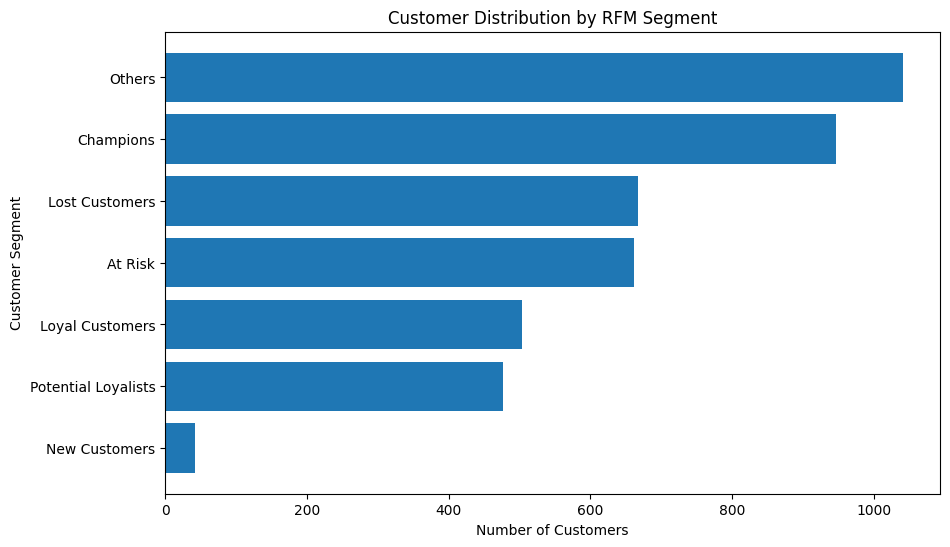

In [179]:
import matplotlib.pyplot as plt

segment_counts_plot = (
    segment_counts
    .sort_values('Customers')
)

plt.figure(figsize=(10, 6))

plt.barh(
    segment_counts_plot['Segment'],
    segment_counts_plot['Customers']
)

plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')
plt.title('Customer Distribution by RFM Segment')

plt.show()

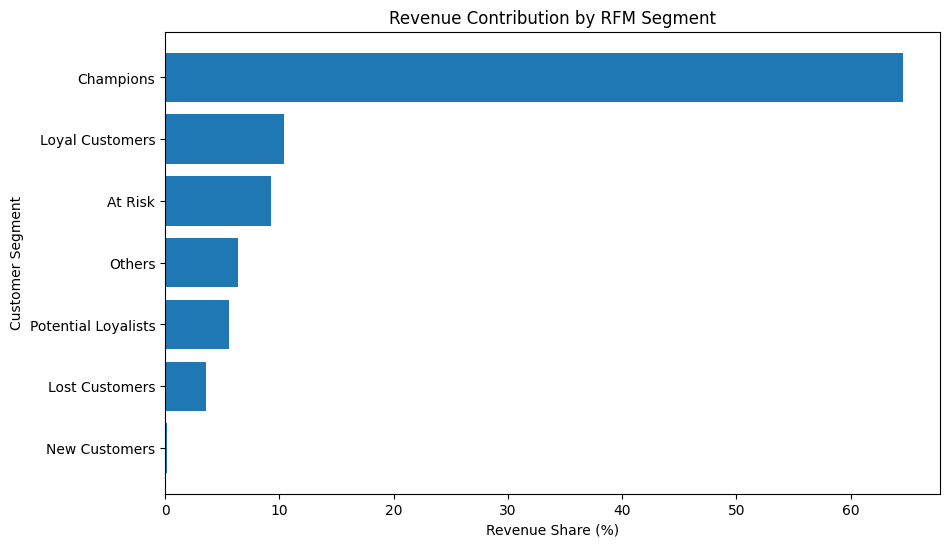

In [180]:
revenue_share_plot = (
    segment_summary
    .sort_values('RevenueShare')
)

plt.figure(figsize=(10, 6))

plt.barh(
    revenue_share_plot['Segment'],
    revenue_share_plot['RevenueShare']
)

plt.xlabel('Revenue Share (%)')
plt.ylabel('Customer Segment')
plt.title('Revenue Contribution by RFM Segment')

plt.show()

In [181]:
segment_summary['CustomerShare'] = (
    segment_summary['Customers']
    / segment_summary['Customers'].sum()
    * 100
)

In [182]:
segment_summary[
    [
        'Segment',
        'Customers',
        'CustomerShare',
        'RevenueShare'
    ]
].sort_values(
    'RevenueShare',
    ascending=False
)

,Segment,Customers,CustomerShare,RevenueShare
1,Champions,947,21.830337,64.585902
3,Loyal Customers,503,11.595205,10.394994
0,At Risk,661,15.237437,9.273937
5,Others,1041,23.997234,6.405575
6,Potential Loyalists,477,10.995851,5.592948
2,Lost Customers,667,15.375749,3.563676
4,New Customers,42,0.968188,0.182967


In [183]:
segment_summary['RevenueIndex'] = (
    segment_summary['RevenueShare']
    / segment_summary['CustomerShare']
)

In [184]:
segment_summary[
    [
        'Segment',
        'CustomerShare',
        'RevenueShare',
        'RevenueIndex'
    ]
].sort_values(
    'RevenueIndex',
    ascending=False
)

,Segment,CustomerShare,RevenueShare,RevenueIndex
1,Champions,21.830337,64.585902,2.958539
3,Loyal Customers,11.595205,10.394994,0.896491
0,At Risk,15.237437,9.273937,0.608628
6,Potential Loyalists,10.995851,5.592948,0.508642
5,Others,23.997234,6.405575,0.266930
2,Lost Customers,15.375749,3.563676,0.231773
4,New Customers,0.968188,0.182967,0.188979


In [185]:
segment_summary['CustomerShare'] = (
    segment_summary['Customers']
    / segment_summary['Customers'].sum()
    * 100
)

In [186]:
segment_summary['RevenueIndex'] = (
    segment_summary['RevenueShare']
    / segment_summary['CustomerShare']
)

In [187]:
rfm_final_summary = segment_summary[
    [
        'Segment',
        'Customers',
        'CustomerShare',
        'Revenue',
        'RevenueShare',
        'RevenueIndex',
        'AvgRevenuePerCustomer',
        'AvgFrequency',
        'AvgRecency'
    ]
].sort_values(
    'RevenueShare',
    ascending=False
)

rfm_final_summary

,Segment,Customers,CustomerShare,Revenue,RevenueShare,RevenueIndex,AvgRevenuePerCustomer,AvgFrequency,AvgRecency
1,Champions,947,21.830337,5755513.220,64.585902,2.958539,6077.627476,11.153115,12.542767
3,Loyal Customers,503,11.595205,926340.321,10.394994,0.896491,1841.630857,5.147117,37.377734
0,At Risk,661,15.237437,826438.371,9.273937,0.608628,1250.284979,3.413011,150.642965
5,Others,1041,23.997234,570826.891,6.405575,0.266930,548.344756,1.356388,74.708934
6,Potential Loyalists,477,10.995851,498410.420,5.592948,0.508642,1044.885577,2.014675,16.624738
2,Lost Customers,667,15.375749,317573.741,3.563676,0.231773,476.122550,1.064468,277.629685
4,New Customers,42,0.968188,16304.940,0.182967,0.188979,388.212857,1.000000,6.857143


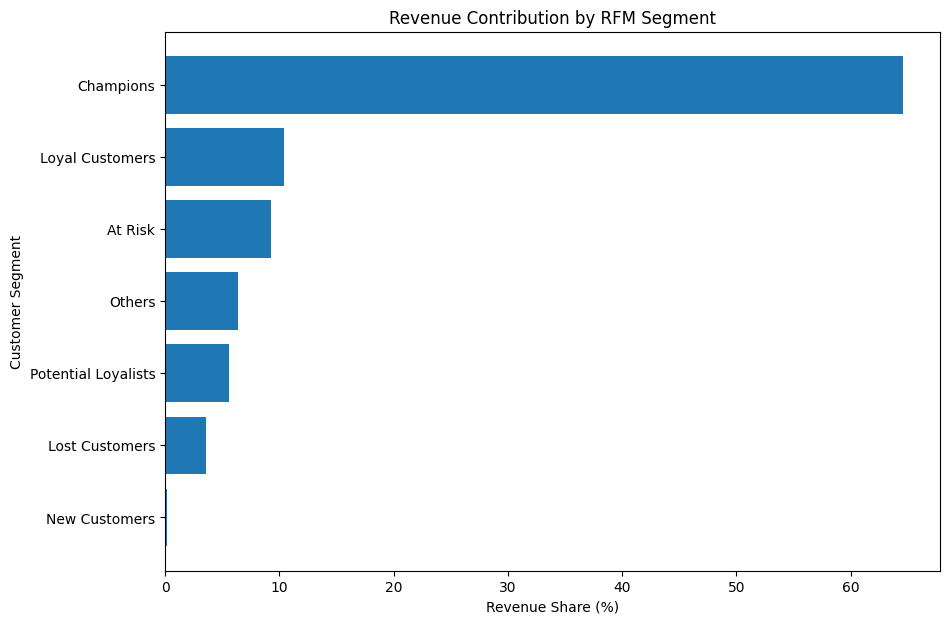

In [188]:
rfm_plot = rfm_final_summary.sort_values(
    'RevenueShare',
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    rfm_plot['Segment'],
    rfm_plot['RevenueShare'],
    label='Revenue Share'
)

plt.xlabel('Revenue Share (%)')
plt.ylabel('Customer Segment')
plt.title('Revenue Contribution by RFM Segment')

plt.show()

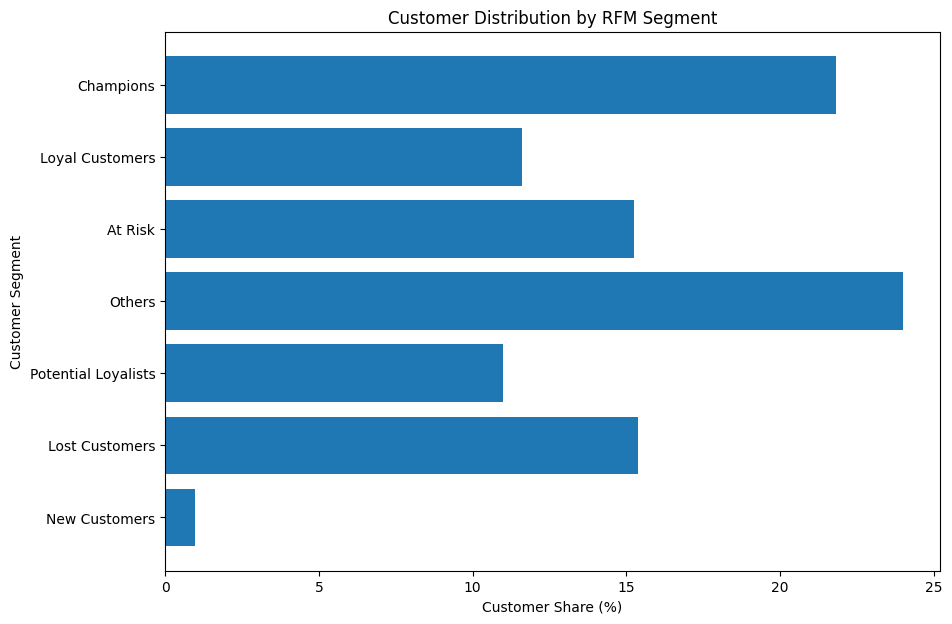

In [189]:
plt.figure(figsize=(10, 7))

plt.barh(
    rfm_plot['Segment'],
    rfm_plot['CustomerShare']
)

plt.xlabel('Customer Share (%)')
plt.ylabel('Customer Segment')
plt.title('Customer Distribution by RFM Segment')

plt.show()

In [190]:
segment_strategy = {
    'Champions':
        'VIP rewards, early access and personalized recommendations',

    'Loyal Customers':
        'Loyalty programs, cross-selling and membership upgrades',

    'Potential Loyalists':
        'Second-purchase incentives and targeted recommendations',

    'New Customers':
        'Welcome offers and onboarding campaigns',

    'At Risk':
        'Win-back campaigns, personalized offers and limited-time discounts',

    'Lost Customers':
        'Low-cost automated reactivation campaigns',

    'Others':
        'General engagement and further behavioral analysis'
}

In [191]:
rfm_final_summary['Strategy'] = (
    rfm_final_summary['Segment']
    .map(segment_strategy)
)

In [192]:
rfm_final_summary[
    [
        'Segment',
        'Customers',
        'CustomerShare',
        'RevenueShare',
        'AvgRecency',
        'AvgFrequency',
        'Strategy'
    ]
]

,Segment,Customers,CustomerShare,RevenueShare,AvgRecency,AvgFrequency,Strategy
1,Champions,947,21.830337,64.585902,12.542767,11.153115,"VIP rewards, early access and personalized rec..."
3,Loyal Customers,503,11.595205,10.394994,37.377734,5.147117,"Loyalty programs, cross-selling and membership..."
0,At Risk,661,15.237437,9.273937,150.642965,3.413011,"Win-back campaigns, personalized offers and li..."
5,Others,1041,23.997234,6.405575,74.708934,1.356388,General engagement and further behavioral anal...
6,Potential Loyalists,477,10.995851,5.592948,16.624738,2.014675,Second-purchase incentives and targeted recomm...
2,Lost Customers,667,15.375749,3.563676,277.629685,1.064468,Low-cost automated reactivation campaigns
4,New Customers,42,0.968188,0.182967,6.857143,1.000000,Welcome offers and onboarding campaigns


In [193]:
monthly_summary.to_csv(
    'monthly_summary.csv',
    index=False
)

final_product_summary.to_csv(
    'product_summary.csv',
    index=False
)

country_summary.to_csv(
    'country_summary.csv',
    index=False
)

rfm_final_summary.to_csv(
    'rfm_summary.csv',
    index=False
)

customer_rfm.to_csv(
    'customer_rfm.csv',
    index=False
)

In [194]:
clean_sales.to_csv(
    'clean_sales.csv',
    index=False
)

In [195]:
monthly_summary.to_csv(
    'monthly_summary.csv',
    index=False
)

final_product_summary.to_csv(
    'product_summary.csv',
    index=False
)

country_summary.to_csv(
    'country_summary.csv',
    index=False
)

customer_rfm.to_csv(
    'customer_rfm.csv',
    index=False
)

rfm_final_summary.to_csv(
    'rfm_summary.csv',
    index=False
)